# Tarea 3 Algoritmos de Aprendizaje Supervisado #
## Regresión Lineal – Vehicle dataset ##
### Jaime Daniel Cerón Rosales ###
### UNAD - 2025 ###

Objetivo: Predecir el precio del automóvil en función de sus atributos.

    1. Realizar un análisis exploratorio de los datos para identificar relaciones entre variables, valores atípicos, tendencias, etc.
    2. Preprocesar los datos limpiándolos, tratando valores faltantes y transformándolos según sea necesario.
    3. Seleccionar las características más relevantes para entrenar el modelo utilizando selección de características.
    4. Dividir el dataset en Train y Test para evaluar correctamente el modelo.
    5. Entrenar el modelo configurando los diferentes hiperparámetros.
    6. Evaluar el desempeño del modelo en el conjunto de Test con métricas como precisión, recall, F1-score, etc.
    7. Realizar las diferentes gráficas que permitan visualizar los resultados del modelo.
    8. Interpretar, analizar y documentar los resultados obtenido.

### 1. Realizar un análisis exploratorio de los datos para identificar relaciones entre variables, valores atípicos, tendencias. ###

In [1]:
# Importaremos librerias necesarias

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el dataset
df = pd.read_csv('C:/Users/jadceron/Documents/vehicledataset/car_data.csv')  # cambia por la ruta de tu archivo

Veremos el tamaño de los datos usando shape:

In [3]:
df.shape

(301, 9)

Miramos los primeros datos del conjunto usando head():

In [5]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Con df.info miramos información general sobre el DataFrame. Esta información incluye el número de filas y columnas, el tipo de datos, el uso de memoria, y más. 

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


Generamos un resumen estadístico de las columnas del DataFrame. Este resumen incluye información sobre la tendencia central, la dispersión y la forma de la distribución de los datos. 

In [10]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


Con df.isna().sum() contamos valores nulos

In [12]:
# Revisar valores nulos
#Missing Values
df.isna().sum() # identify Missing Value

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

### 2. Preprocesar los datos limpiándolos, tratando valores faltantes y transformándolos según sea necesario ###

In [ ]:
Eliminamos car_name del dataset, el nombre no sera relevante para nuestro analisis

In [26]:
# Delete car name from dataset
df= df.drop(columns='Car_Name')
df

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,5
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,6
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,2
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,8
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,5
...,...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,3
297,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,4
298,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,10
299,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,2


Crearemos una nueva columna llamada Edad del vehiculo con el fin de saber cuantos años tiene un vehiculo.

In [23]:
df2= df  # create a copy of dataframe

for i in range(len(df)):
    df2['Age']= df['Year'].max()+1-df['Year']
df2

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,5
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,6
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,2
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,8
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,5
...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,3
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,4
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,10
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,2


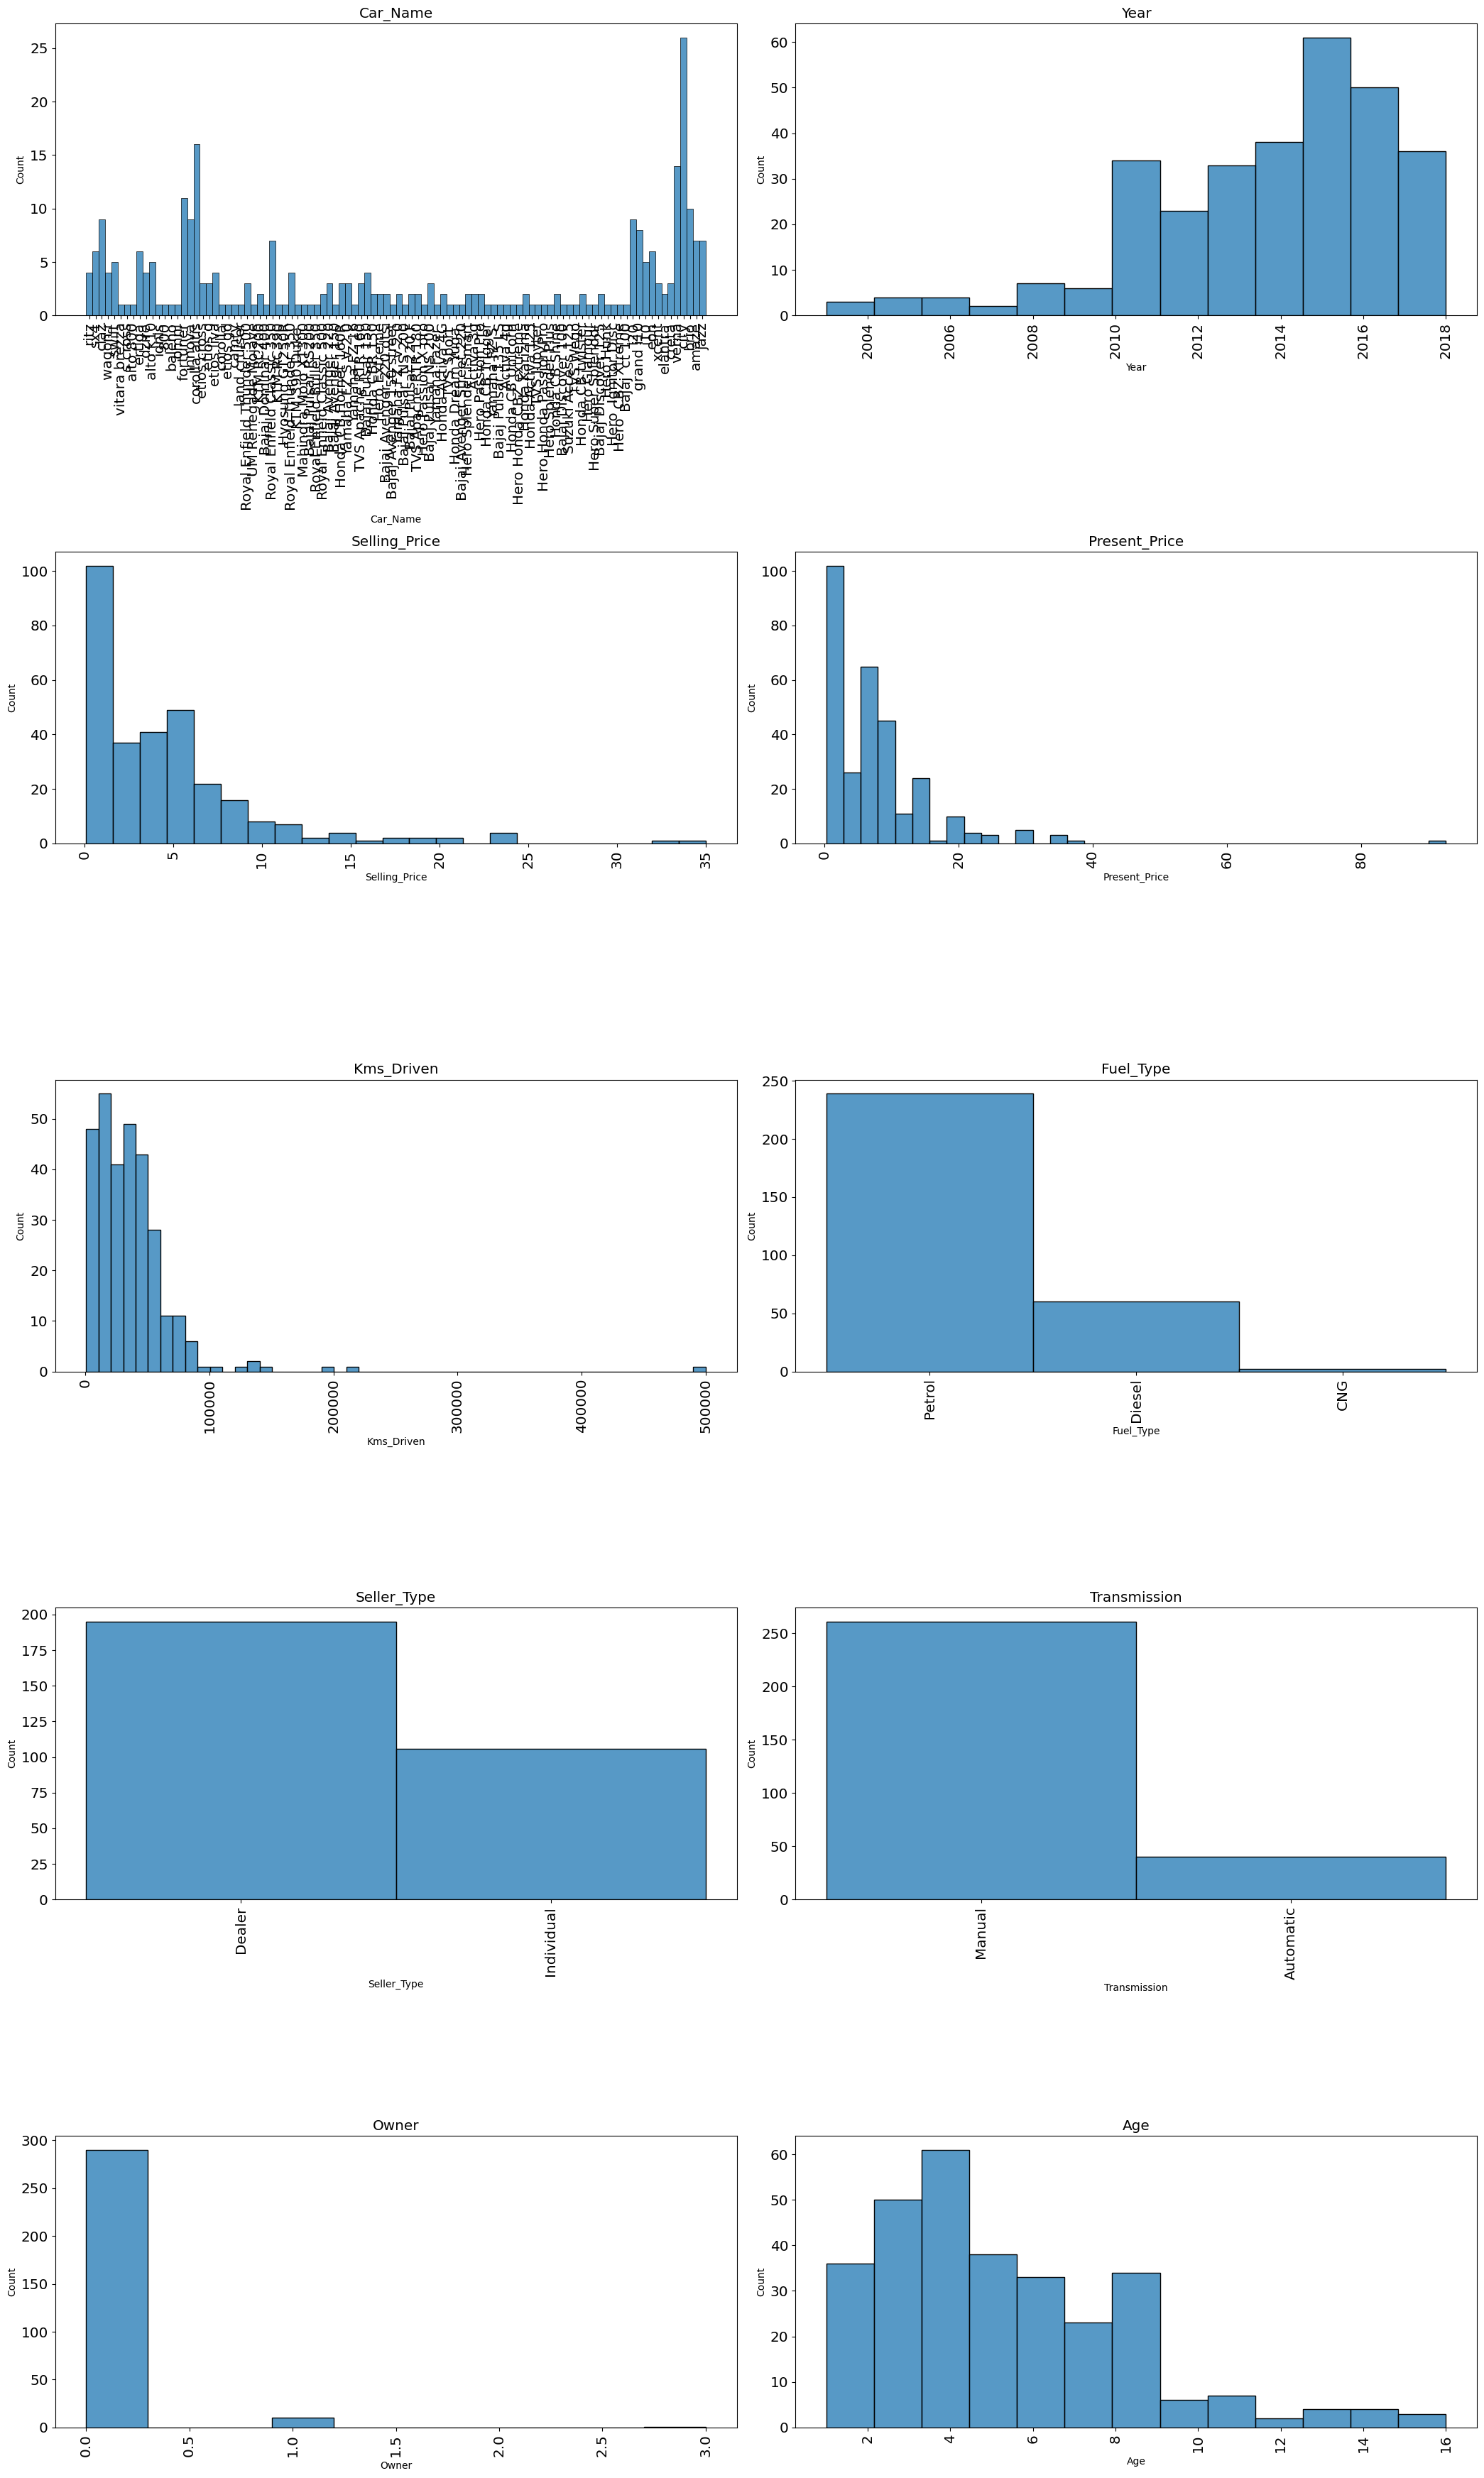

In [25]:
n = len(df.columns)
rows = (n + 5) // 3  

plt.figure(figsize=(21, rows * 7))  

for i, col in enumerate(df.columns):
    plt.subplot(rows, 2, i + 1) 
    sns.histplot(x=df[col])
    plt.title(f'{col}', size='x-large')
    plt.xticks(rotation=90,size='x-large')
    plt.yticks(size='x-large')


plt.tight_layout() 
plt.show()

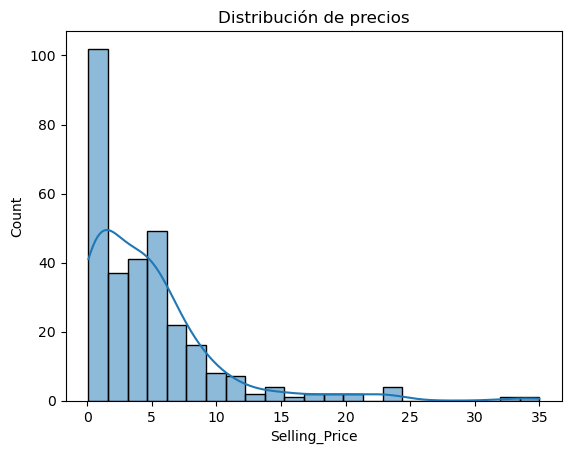

In [18]:
# Distribución de precios
sns.histplot(df['Selling_Price'], kde=True)
plt.title('Distribución de precios')
plt.show()

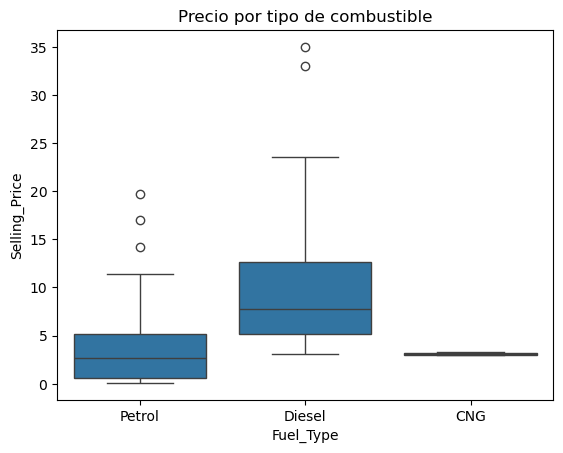

In [19]:
# Boxplots para identificar outliers
sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price')
plt.title('Precio por tipo de combustible')
plt.show()

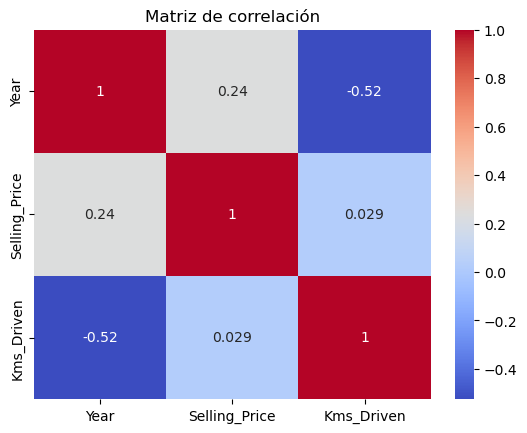

In [20]:
# Correlación numérica
numericas = ['Year', 'Selling_Price', 'Kms_Driven']
sns.heatmap(df[numericas].corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

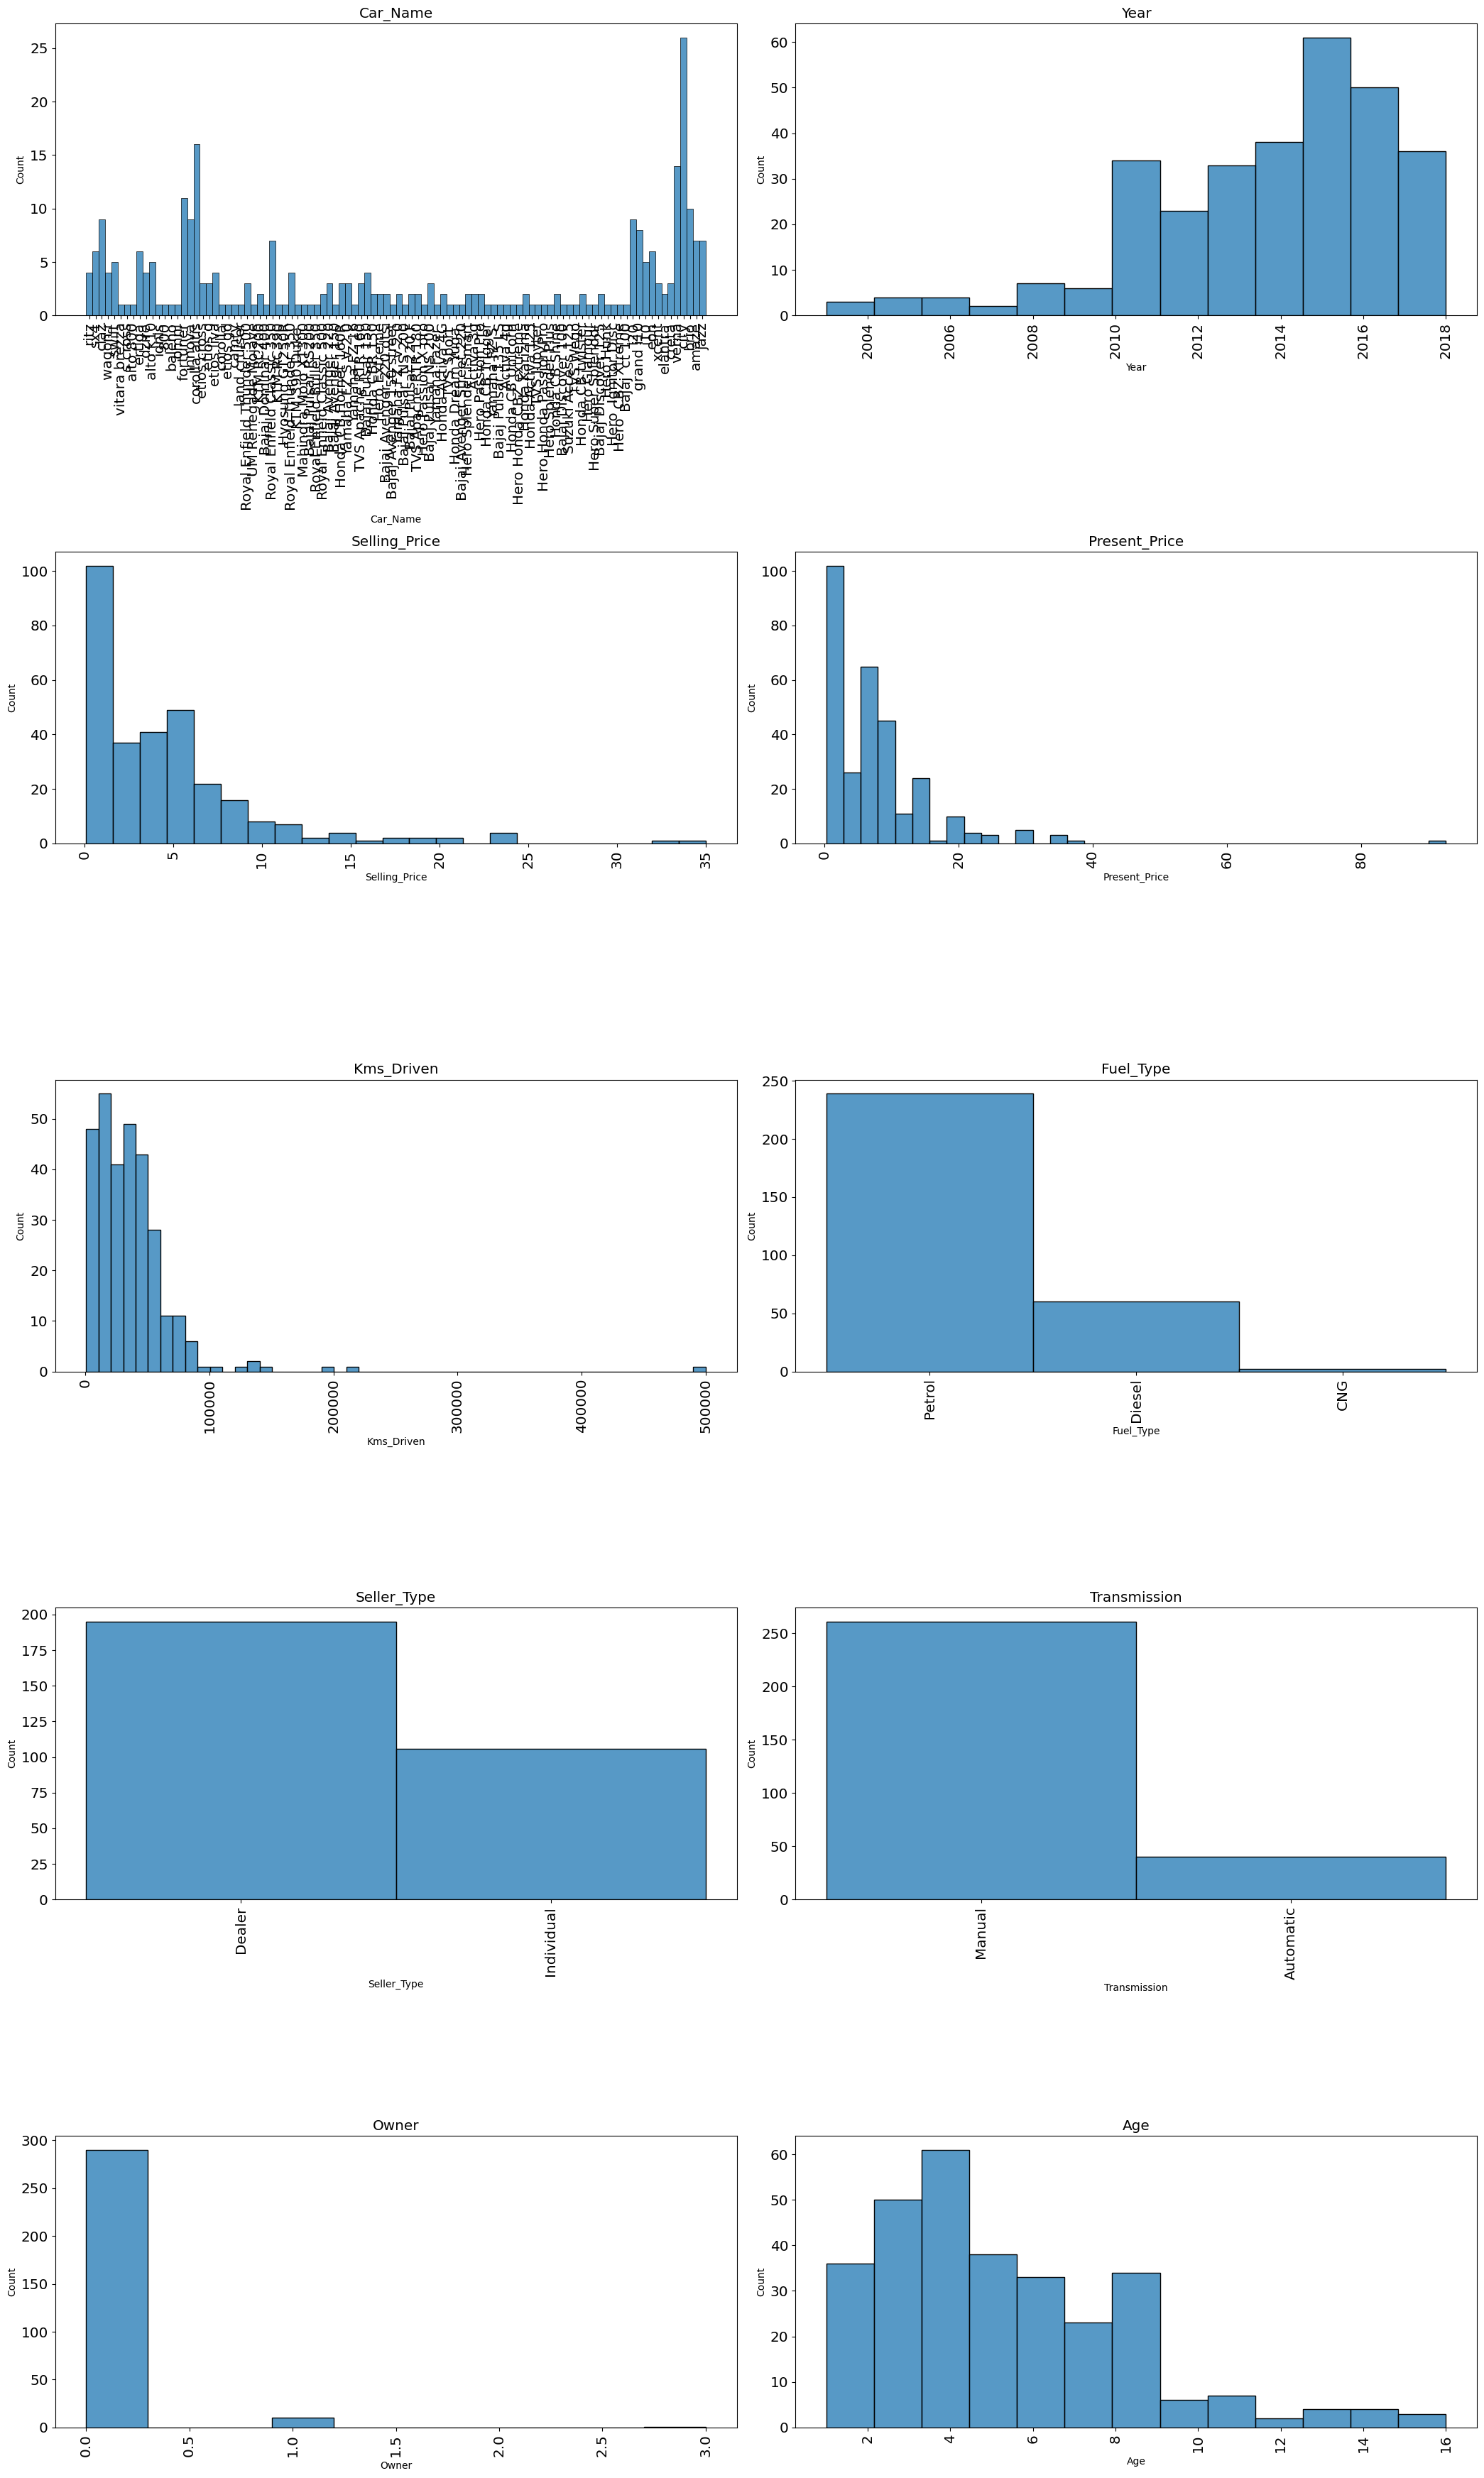

In [21]:
n = len(df.columns)
rows = (n + 5) // 3  

plt.figure(figsize=(21, rows * 7))  

for i, col in enumerate(df.columns):
    plt.subplot(rows, 2, i + 1) 
    sns.histplot(x=df[col])
    plt.title(f'{col}', size='x-large')
    plt.xticks(rotation=90,size='x-large')
    plt.yticks(size='x-large')


plt.tight_layout() 
plt.show() 